In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
dataset = pd.read_csv("powerplant_data.csv")

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [8]:
dataset.shape

(9568, 5)

In [9]:
dataset.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [11]:
dataset.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


<Figure size 1500x800 with 0 Axes>

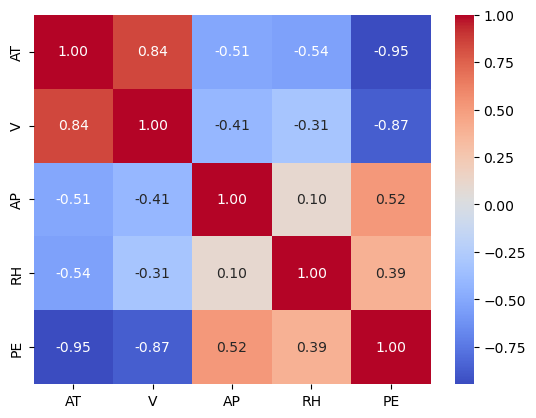

<Figure size 1500x800 with 0 Axes>

In [18]:
corr1 = dataset.corr()
sns.heatmap(
    corr1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.figure(figsize=(15, 8))




In [19]:
corr1["PE"]

AT   -0.948128
V    -0.869780
AP    0.518429
RH    0.389794
PE    1.000000
Name: PE, dtype: float64

<Axes: ylabel='PE'>

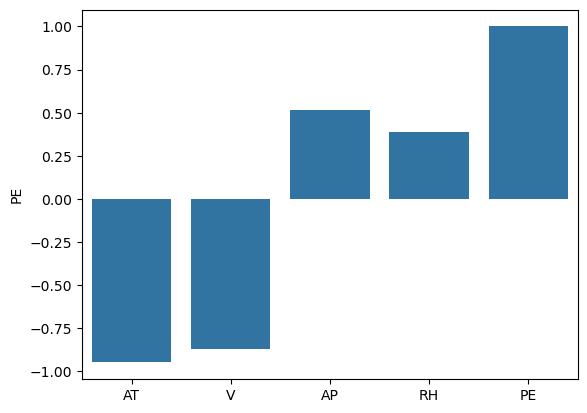

In [26]:
sns.barplot(corr1['PE'])

In [28]:
from sklearn.model_selection import train_test_split,GridSearchCV

X_trian,X_test,y_train,y_test = train_test_split(
    dataset.drop('PE',axis=1),dataset['PE'],
    random_state=42
)

In [29]:
X_trian.shape

(7176, 4)

In [30]:
X_test.shape

(2392, 4)

In [ ]:
from sklearn.preprocessing import StandardScaler

sclr = StandardScaler()

X_train_scled = sclr.fit_transform(X_trian)
X_test_scled = sclr.fit_transform(X_test)

In [35]:
from sklearn.ensemble import RandomForestRegressor
model  = RandomForestRegressor()

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
     n_jobs=-1,
)

grid.fit(X_train_scled,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [36]:
print("best perameters :",grid.best_params_)
print("best score : ",grid.best_score_)

best perameters : {'bootstrap': False, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
best score :  0.962599275838369


In [48]:
model = RandomForestRegressor(n_estimators=300,
                              max_depth=9
                              ,max_features='log2',
                              min_samples_leaf=2,min_samples_split=5,
                              bootstrap=True)

model.fit(X_train_scled,y_train)
train_pred = model.predict(X_train_scled)
test_pred= model.predict(X_test_scled)

# evaluation 

from sklearn.metrics import r2_score,mean_squared_error
print("--------------------------------------------------------")
print("train_pred r2_score:",r2_score(y_train,train_pred))
print("test_pred r2_score:",r2_score(y_test,test_pred))
print("--------------------------------------------------------")
print("train_pred mean_squared_error:",mean_squared_error(y_train,train_pred))
print("test_pred mean_squared_error:",mean_squared_error(y_test,test_pred))
print("--------------------------------------------------------")

--------------------------------------------------------
train_pred r2_score: 0.9686504375412232
test_pred r2_score: 0.9542347125186328
--------------------------------------------------------
train_pred mean_squared_error: 9.163542008347143
test_pred mean_squared_error: 13.18494833621282
--------------------------------------------------------


# using neural network

In [49]:
X_train_scaled = sclr.fit_transform(X_trian)
X_test_scaled = sclr.fit_transform(X_test)

import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [50]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [54]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_trian.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
                                        
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [55]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [56]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 205928.50902777776 & val loss = 203776.046875
epoch 2/100 ==> train loss = 195746.37416666668 & val loss = 182716.953125
epoch 3/100 ==> train loss = 160783.66038194444 & val loss = 137191.625
epoch 4/100 ==> train loss = 119251.20975694444 & val loss = 106333.5703125
epoch 5/100 ==> train loss = 100894.57234375 & val loss = 96948.0234375
epoch 6/100 ==> train loss = 92461.043125 & val loss = 87346.65625
epoch 7/100 ==> train loss = 77751.38369791667 & val loss = 66371.328125
epoch 8/100 ==> train loss = 53094.375572916666 & val loss = 38736.92578125
epoch 9/100 ==> train loss = 23521.66578125 & val loss = 10143.572265625
epoch 10/100 ==> train loss = 4178.85721110026 & val loss = 1084.2127685546875
epoch 11/100 ==> train loss = 605.0878904215494 & val loss = 386.0751953125
epoch 12/100 ==> train loss = 344.6464924112956 & val loss = 291.3280334472656
epoch 13/100 ==> train loss = 275.5159266153971 & val loss = 238.65455627441406
epoch 14/100 ==> train loss

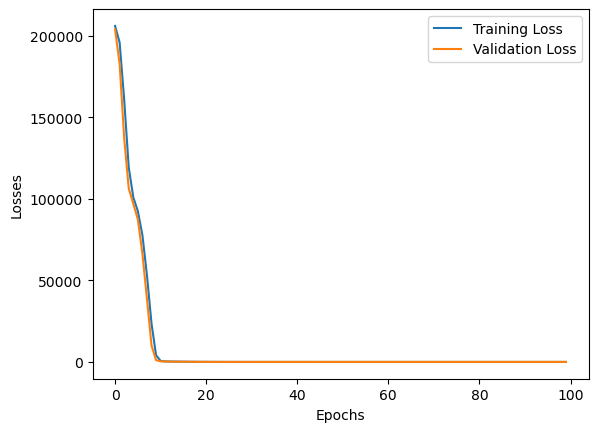

In [57]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [58]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [59]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 19.844032287597656
Testing MSE: 18.53761100769043


In [60]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

r^2 score = 0.9356554955985845


,Predicted Values,Actual Values
0,434.906891,433.27
1,436.524445,438.16
2,461.022125,458.42
3,476.363525,480.82
4,434.422363,441.41
...,...,...
2387,453.630371,446.70
2388,433.031250,430.82
2389,433.461792,440.10
2390,438.232300,439.39
